# OpenAlex API로 살펴보는 LLM 연구의 확산과 변화

OpenAlex API를 이용하여 LLM 연구가 언제, 어디서, 어떤 주제로 커지고 있는지 함께 살펴봅시다.

## 실습 질문
> OpenAlex 데이터로 봤을 때, LLM 연구는 얼마나 빠르게 확산되고 있을까?

## 오늘 해볼 것
1. OpenAlex API의 기본 구조 가볍게 익히기
2. `works` 엔드포인트에서 논문 데이터 직접 가져오기
3. cursor pagination으로 여러 페이지의 데이터 수집
4. 연도, 국가, 기관, OpenAlex Topic을 기준으로 연구 흐름 파악
5. abstract를 복원하여 간단한 토픽모델링까지 확장



## 0. 환경 설정 및 패키지 로드

In [ ]:
!pip -q install pandas requests matplotlib tqdm scikit-learn

In [ ]:
import time
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import Counter
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
# Check the operating system and install font if necessary (e.g., for Colab)
if platform.system() == 'Linux':
    !apt-get update -qq > /dev/null
    !apt-get install -y fonts-nanum > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')

# Set font for matplotlib
plt.rcParams['font.family'] = 'NanumBarunGothic' if platform.system() == 'Linux' else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # Prevent minus sign from breaking

## 1. OpenAlex API 기본 구조

OpenAlex: 논문과 저자, 기관, 학술지, 주제 정보를 연결해 둔 학술 메타데이터 데이터베이스

주로 사용하는 엔티티:

- `works`: 논문, 책, 학술 출력물
- `authors`: 저자
- `institutions`: 기관
- `sources`: 저널, 컨퍼런스, 저장소
- `topics`: 연구 주제
- `publishers`, `funders`, `concepts`: 출판사, 연구비 지원기관, 기존 개념 분류

이 중에서 `works`를 중심으로 데이터를 모아봅시다.

[works 스키마 확인해보기](https://drive.google.com/file/d/1bt-Q1QhBjz_vifmOwJ7OjCeHJ0wZvbf0/view?usp=sharing)

In [ ]:
BASE_URL = "https://api.openalex.org"

# OpenAlex polite pool 사용 권장: 본인 이메일로 바꿔주세요.
USER_EMAIL = "your@email.com"

# OpenAlex 계정 생성 후 무료로 API KEY를 받을 수 있습니다. https://openalex.org/settings/api-key
OPENALEX_API_KEY = "YOUR API KEY"

HEADERS = {
    "User-Agent": f"mailto:{USER_EMAIL}"
}

## 2. 쿼리 설정하기

쿼리 (검색어) 설정은 연구동향 분석에서 중요함.

사용할 수 있는 후보 쿼리:

- `large language model`
- `LLM`
- `GPT`
- `generative ai`
- `artificial intelligence`

이번 실습은 `large language model`를 이용하여 진행.

In [ ]:
SEARCH_QUERY = "large language model"
START_YEAR = 2020
END_YEAR = 2025

FILTER = f"from_publication_date:{START_YEAR}-01-01,to_publication_date:{END_YEAR}-12-31"
PER_PAGE = 200
MAX_RECORDS = 5000

## 3. API 한 번 호출해보기

In [ ]:
url = f"{BASE_URL}/works"
params = {
    "search": SEARCH_QUERY,
    "filter": FILTER,
    "per-page": 5,
    "mailto": USER_EMAIL,
    "api_key": OPENALEX_API_KEY,
}

response = requests.get(url, params=params, headers=HEADERS)
response.raise_for_status()
data = response.json()

print("총 검색 결과 수:", data["meta"]["count"])
print("첫 번째 논문 제목:", data["results"][0]["title"])

총 검색 결과 수: 1970872
첫 번째 논문 제목: ChatGPT for good? On opportunities and challenges of large language models for education


In [ ]:
sample_work = data["results"][0]
sample_work.keys()

dict_keys(['id', 'doi', 'title', 'display_name', 'relevance_score', 'publication_year', 'publication_date', 'ids', 'language', 'primary_location', 'type', 'indexed_in', 'open_access', 'authorships', 'institutions', 'countries_distinct_count', 'institutions_distinct_count', 'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci', 'has_fulltext', 'cited_by_count', 'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext', 'is_xpac', 'primary_topic', 'topics', 'keywords', 'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location', 'sustainable_development_goals', 'awards', 'funders', 'has_content', 'content_urls', 'referenced_works_count', 'referenced_works', 'related_works', 'abstract_inverted_index', 'counts_by_year', 'updated_date', 'created_date'])

## 4. Cursor pagination으로 여러 건 수집하기

여러 페이지의 데이터를 가져올 때는 cursor pagination을 활용할 수 있음.

`cursor=*`로 시작하며, 응답에 들어 있는 `meta.next_cursor`를 다음 요청에 전달.

In [ ]:
def fetch_openalex_works(search_query, filter_query, max_records=5000, per_page=200, mailto=USER_EMAIL, sleep_sec=0.1):
    works = []
    cursor = "*"
    pbar = tqdm(total=max_records)

    while len(works) < max_records:
        params = {
            "search": search_query,
            "filter": filter_query,
            "per-page": per_page,
            "cursor": cursor,
            "mailto": mailto,
            "api_key": OPENALEX_API_KEY
        }

        r = requests.get(f"{BASE_URL}/works", params=params, headers=HEADERS)
        r.raise_for_status()
        payload = r.json()

        results = payload.get("results", [])
        if not results:
            break

        remaining = max_records - len(works)
        works.extend(results[:remaining])
        pbar.update(min(len(results), remaining))

        cursor = payload["meta"].get("next_cursor")
        if not cursor:
            break

        time.sleep(sleep_sec)

    pbar.close()
    return works

In [ ]:
works = fetch_openalex_works(
    search_query=SEARCH_QUERY,
    filter_query=FILTER,
    max_records=MAX_RECORDS,
    per_page=PER_PAGE
)

len(works)

  0%|          | 0/5000 [00:00<?, ?it/s]

5000

## 5. 필요한 필드만 추출해서 DataFrame 만들기

OpenAlex record는 중첩 구조가 많으므로, 분석의 편의성을 위해 필요한 필드만 골라서 DataFrame을 생성할 수 있음.

In [ ]:
def extract_work_row(work):
    primary_location = work.get("primary_location") or {}
    source = primary_location.get("source") or {}
    primary_topic = work.get("primary_topic") or {}
    topic_domain = primary_topic.get("domain") or {}
    topic_field = primary_topic.get("field") or {}
    topic_subfield = primary_topic.get("subfield") or {}

    authorships = work.get("authorships") or []
    countries = []
    institutions = []

    for authorship in authorships:
        countries.extend(authorship.get("countries") or [])
        for inst in authorship.get("institutions") or []:
            institutions.append({
                "id": inst.get("id"),
                "display_name": inst.get("display_name"),
                "country_code": inst.get("country_code"),
                "type": inst.get("type")
            })

    return {
        "id": work.get("id"),
        "doi": work.get("doi"),
        "title": work.get("title"),
        "publication_year": work.get("publication_year"),
        "publication_date": work.get("publication_date"),
        "type": work.get("type"),
        "cited_by_count": work.get("cited_by_count"),
        "is_oa": (work.get("open_access") or {}).get("is_oa"),
        "source_name": source.get("display_name"),
        "source_type": source.get("type"),
        "primary_topic": primary_topic.get("display_name"),
        "primary_topic_id": primary_topic.get("id"),
        "primary_topic_score": primary_topic.get("score"),
        "primary_topic_subfield": topic_subfield.get("display_name"),
        "primary_topic_field": topic_field.get("display_name"),
        "primary_topic_domain": topic_domain.get("display_name"),
        "countries": sorted(set(countries)),
        "institutions": institutions,
        "num_authors": len(authorships),
    }

In [ ]:
rows = [extract_work_row(w) for w in works]
df = pd.DataFrame(rows)

df.head()

,id,doi,title,publication_year,publication_date,type,cited_by_count,is_oa,source_name,source_type,primary_topic,primary_topic_id,primary_topic_score,primary_topic_subfield,primary_topic_field,primary_topic_domain,countries,institutions,num_authors
0,https://openalex.org/W4323655724,https://doi.org/10.1016/j.lindif.2023.102274,ChatGPT for good? On opportunities and challen...,2023,2023-03-09,article,5058,True,Learning and Individual Differences,journal,Artificial Intelligence in Healthcare and Educ...,https://openalex.org/T11636,0.9825,Health Informatics,Medicine,Health Sciences,[DE],"[{'id': 'https://openalex.org/I62916508', 'dis...",23
1,https://openalex.org/W4384561707,https://doi.org/10.1038/s41591-023-02448-8,Large language models in medicine,2023,2023-07-17,review,3305,False,Nature Medicine,journal,Artificial Intelligence in Healthcare and Educ...,https://openalex.org/T11636,0.9983,Health Informatics,Medicine,Health Sciences,"[GB, SG, US]","[{'id': 'https://openalex.org/I241749', 'displ...",6
2,https://openalex.org/W4384071683,https://doi.org/10.1038/s41586-023-06291-2,Large language models encode clinical knowledge,2023,2023-07-12,article,3170,True,Nature,journal,Topic Modeling,https://openalex.org/T10028,0.9992,Artificial Intelligence,Computer Science,Physical Sciences,"[GB, US]","[{'id': 'https://openalex.org/I1291425158', 'd...",32
3,https://openalex.org/W4391136507,https://doi.org/10.1145/3641289,A Survey on Evaluation of Large Language Models,2024,2024-01-23,article,2452,False,ACM Transactions on Intelligent Systems and Te...,journal,Topic Modeling,https://openalex.org/T10028,0.9989,Artificial Intelligence,Computer Science,Physical Sciences,"[CN, HK, US]","[{'id': 'https://openalex.org/I194450716', 'di...",16
4,https://openalex.org/W4319662928,https://doi.org/10.1371/journal.pdig.0000198,Performance of ChatGPT on USMLE: Potential for...,2023,2023-02-09,article,3559,True,PLOS Digital Health,journal,Artificial Intelligence in Healthcare and Educ...,https://openalex.org/T11636,0.9996,Health Informatics,Medicine,Health Sciences,[US],"[{'id': 'https://openalex.org/I4210087915', 'd...",11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      5000 non-null   object 
 1   doi                     4999 non-null   object 
 2   title                   5000 non-null   object 
 3   publication_year        5000 non-null   int64  
 4   publication_date        5000 non-null   object 
 5   type                    5000 non-null   object 
 6   cited_by_count          5000 non-null   int64  
 7   is_oa                   5000 non-null   bool   
 8   source_name             3730 non-null   object 
 9   source_type             3730 non-null   object 
 10  primary_topic           5000 non-null   object 
 11  primary_topic_id        5000 non-null   object 
 12  primary_topic_score     5000 non-null   float64
 13  primary_topic_subfield  5000 non-null   object 
 14  primary_topic_field     5000 non-null   

## 6. 연도별 LLM 연구 성장 분석

연도별 전체 건수는 OpenAlex의 group_by=publication_year 결과를 사용합.

위에서 수집한 works 샘플 크기와 무관하게 전체 검색 결과의 연도별 분포의 확인이 가능함.

In [ ]:
# 5000개 샘플로 groupby
year_counts = (
    df.groupby("publication_year")
    .size()
    .reset_index(name="num_works")
    .sort_values("publication_year")
)

year_counts

,publication_year,num_works
0,2020,10
1,2021,26
2,2022,129
3,2023,1548
4,2024,2454
5,2025,833


In [ ]:
def count_openalex_works_by_year(search_query, filter_query):
    params = {
        "search": search_query,
        "filter": filter_query,
        "group_by": "publication_year",
        "per-page": 200,
        "mailto": USER_EMAIL,
        "api_key": OPENALEX_API_KEY,
    }

    r = requests.get(f"{BASE_URL}/works", params=params)
    r.raise_for_status()
    payload = r.json()

    year_counts = pd.DataFrame(payload["group_by"])
    year_counts = year_counts.rename(columns={
        "key": "publication_year",
        "count": "num_works"
    })
    year_counts["publication_year"] = year_counts["publication_year"].astype(int)
    year_counts = year_counts.sort_values("publication_year").reset_index(drop=True)

    return year_counts[["publication_year", "num_works"]]


year_counts = count_openalex_works_by_year(SEARCH_QUERY, FILTER)
year_counts

,publication_year,num_works
0,2020,205144
1,2021,227429
2,2022,249390
3,2023,386761
4,2024,415941
5,2025,486207


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


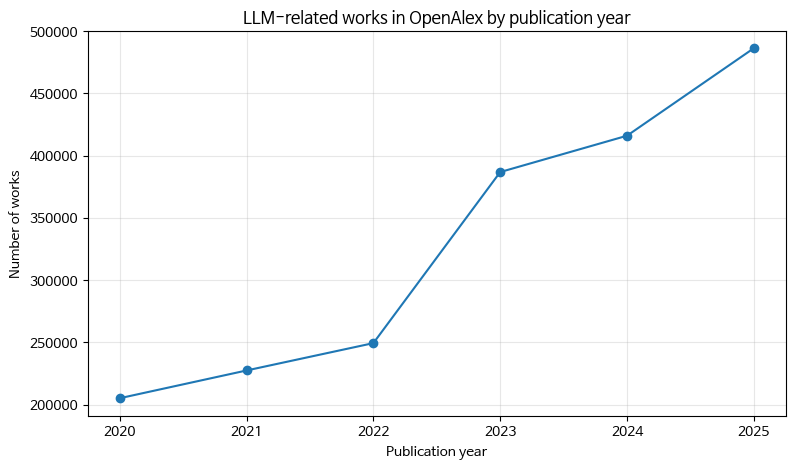

In [ ]:
import matplotlib.font_manager as fm
import platform

plt.figure(figsize=(9, 5))
plt.plot(year_counts["publication_year"], year_counts["num_works"], marker="o")
plt.title("LLM-related works in OpenAlex by publication year")
plt.xlabel("Publication year")
plt.ylabel("Number of works")
plt.grid(True, alpha=0.3)
plt.show()

## 7. 샘플에서 인용 수 보기

인용 수는 앞에서 수집한 works 샘플 기준으로 확인. (전체 검색 결과의 인용 합계가 아님!)

In [ ]:
sample_year_citations = (
    df.groupby("publication_year")
    .agg(
        sample_works=("id", "count"),
        sample_total_citations=("cited_by_count", "sum"),
        sample_avg_citations=("cited_by_count", "mean")
    )
    .reset_index()
    .sort_values("publication_year")
)

sample_year_citations

,publication_year,sample_works,sample_total_citations,sample_avg_citations
0,2020,10,9825,982.500000
1,2021,26,55984,2153.230769
2,2022,129,41407,320.984496
3,2023,1548,220959,142.738372
4,2024,2454,121968,49.701711
5,2025,833,44267,53.141657


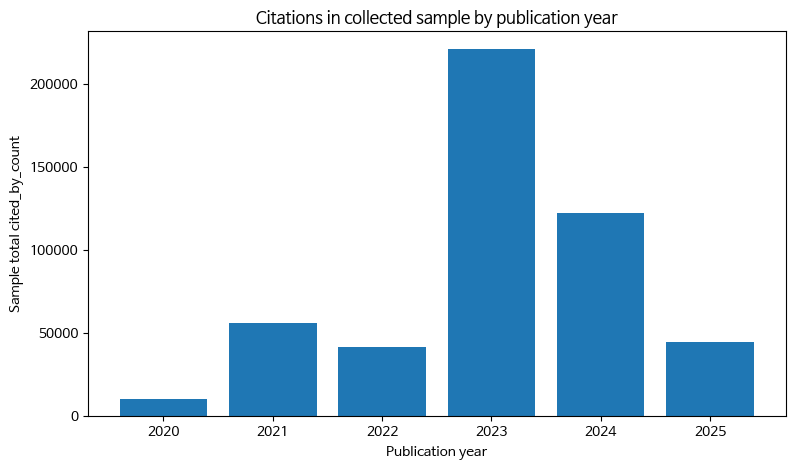

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(sample_year_citations["publication_year"], sample_year_citations["sample_total_citations"])
plt.title("Citations in collected sample by publication year")
plt.xlabel("Publication year")
plt.ylabel("Sample total cited_by_count")
plt.show()

## 9. 국가별 분석

OpenAlex의 `authorships.countries`를 사용해 국가별 분포 확인.

한 논문에 여러 국가가 함께 등장할 수 있으므로, 각 국가에 1건씩 세는 full counting 방식으로 계산.

In [ ]:
country_counter = Counter()

for countries in df["countries"]:
    for country in countries:
        country_counter[country] += 1

country_df = pd.DataFrame(country_counter.items(), columns=["country", "num_works"])
country_df = country_df.sort_values("num_works", ascending=False).reset_index(drop=True)

country_df.head(20)

,country,num_works
0,US,1790
1,CN,1012
2,GB,402
3,DE,310
4,CA,260
5,AU,221
6,HK,216
7,SG,193
8,KR,133
9,IT,126


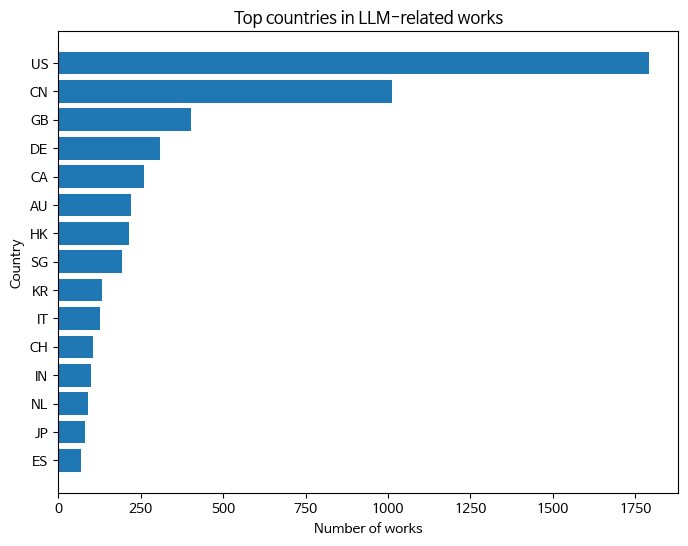

In [ ]:
top_country_df = country_df.head(15).sort_values("num_works")

plt.figure(figsize=(8, 6))
plt.barh(top_country_df["country"], top_country_df["num_works"])
plt.title("Top countries in LLM-related works")
plt.xlabel("Number of works")
plt.ylabel("Country")
plt.show()

## 10. 기관별 분석
기관은 이름뿐 아니라 OpenAlex institution ID를 함께 사용.

* `display_name`: 사람이 읽기 좋은 기관명
* `id`: OpenAlex에서 기관을 구분하는 고유 ID
* `country_code`: 기관 국가 코드

같은 논문에 같은 기관이 여러 번 등장할 수 있으므로, 논문 단위로 중복 기관은 한 번만 집계.

In [ ]:
institution_counter = Counter()
institution_meta = {}

for institutions in df["institutions"]:
    seen_institution_ids = set()

    for inst in institutions:
        inst_id = inst.get("id")
        inst_name = inst.get("display_name")

        if not inst_id or inst_id in seen_institution_ids:
            continue

        institution_counter[inst_id] += 1
        institution_meta[inst_id] = {
            "institution_id": inst_id,
            "institution": inst_name,
            "country": inst.get("country_code"),
            "type": inst.get("type")
        }
        seen_institution_ids.add(inst_id)

institution_df = pd.DataFrame(
    [
        {
            **institution_meta[inst_id],
            "num_works": count
        }
        for inst_id, count in institution_counter.items()
    ]
).sort_values("num_works", ascending=False).reset_index(drop=True)

institution_df.head(20)

,institution_id,institution,country,type,num_works
0,https://openalex.org/I97018004,Stanford University,US,education,142
1,https://openalex.org/I136199984,Harvard University,US,education,119
2,https://openalex.org/I99065089,Tsinghua University,CN,education,113
3,https://openalex.org/I165932596,National University of Singapore,SG,education,95
4,https://openalex.org/I20231570,Peking University,CN,education,75
5,https://openalex.org/I172675005,Nanyang Technological University,SG,education,71
6,https://openalex.org/I76130692,Zhejiang University,CN,education,69
7,https://openalex.org/I183067930,Shanghai Jiao Tong University,CN,education,68
8,https://openalex.org/I889458895,University of Hong Kong,HK,education,67
9,https://openalex.org/I78577930,Columbia University,US,education,67


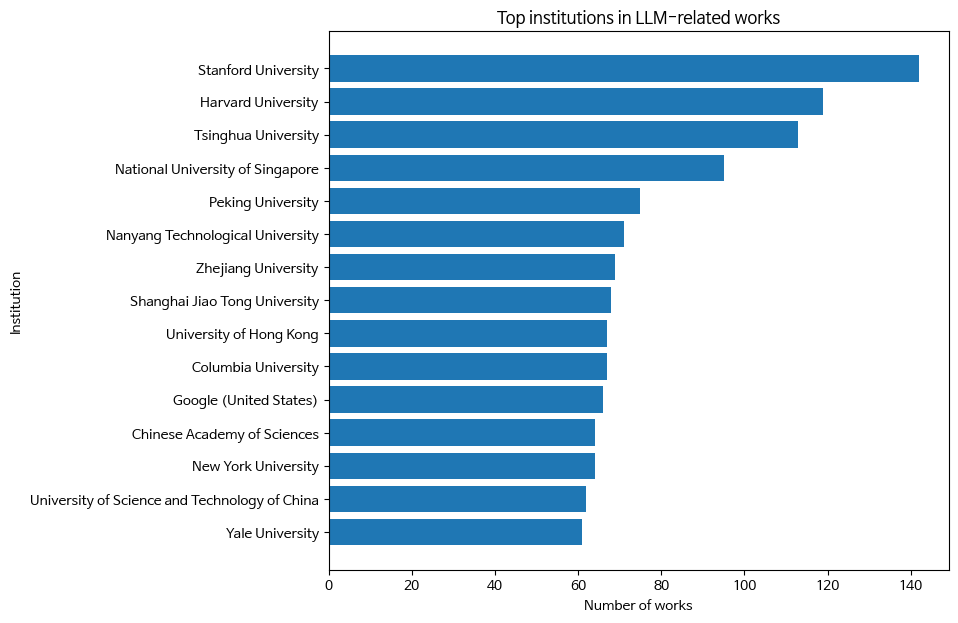

In [ ]:
top_inst_df = institution_df.head(15).sort_values("num_works")

plt.figure(figsize=(8, 7))
plt.barh(top_inst_df["institution"], top_inst_df["num_works"])
plt.title("Top institutions in LLM-related works")
plt.xlabel("Number of works")
plt.ylabel("Institution")
plt.show()

## 11. Topic 분석
OpenAlex의 `primary_topic`을 사용해 LLM 관련 논문들이 어떤 주제에 많이 배정되어 있는지 확인 가능.

이 값은 저자가 직접 고른 키워드보단 OpenAlex가 구축한 주제 분류임에 주의.

In [ ]:
topic_df = (
    df.dropna(subset=["primary_topic"])
    .groupby("primary_topic")
    .size()
    .reset_index(name="num_works")
    .sort_values("num_works", ascending=False)
)

topic_df.head(20)

,primary_topic,num_works
402,Topic Modeling,1509
33,Artificial Intelligence in Healthcare and Educ...,744
290,Natural Language Processing Techniques,251
370,Software Engineering Research,131
287,Multimodal Machine Learning Applications,125
259,Machine Learning in Materials Science,93
258,Machine Learning in Healthcare,89
273,Mental Health via Writing,68
334,Recommender Systems and Techniques,65
374,Software Testing and Debugging Techniques,57


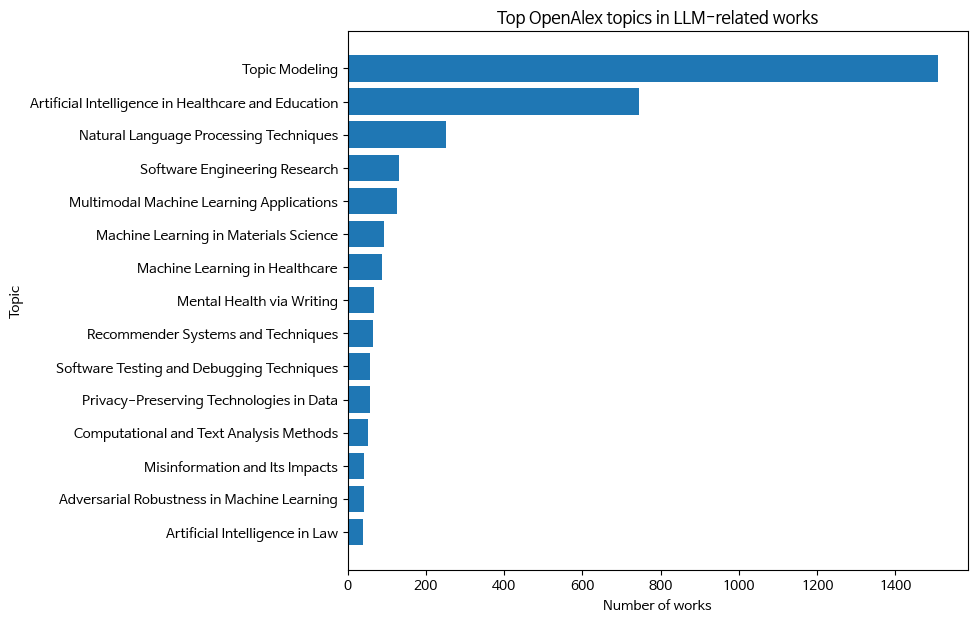

In [ ]:
top_topic_df = topic_df.head(15).sort_values("num_works")

plt.figure(figsize=(8, 7))
plt.barh(top_topic_df["primary_topic"], top_topic_df["num_works"])
plt.title("Top OpenAlex topics in LLM-related works")
plt.xlabel("Number of works")
plt.ylabel("Topic")
plt.show()

## 12. 연도별 Topic 변화
많이 등장한 topic들이 연도별 변화 분석. LLM 연구가 어느 주제 영역에서 빠르게 커졌는지 살펴볼 수 있음.

In [ ]:
top_topics = topic_df.head(8)["primary_topic"].tolist()

topic_year_df = (
    df[df["primary_topic"].isin(top_topics)]
    .groupby(["publication_year", "primary_topic"])
    .size()
    .reset_index(name="num_works")
)

topic_year_pivot = topic_year_df.pivot(
    index="publication_year",
    columns="primary_topic",
    values="num_works"
).fillna(0)

topic_year_pivot

primary_topic,Artificial Intelligence in Healthcare and Education,Machine Learning in Healthcare,Machine Learning in Materials Science,Mental Health via Writing,Multimodal Machine Learning Applications,Natural Language Processing Techniques,Software Engineering Research,Topic Modeling
publication_year,,,,,,,,
2020,0.0,0.0,0.0,0.0,1.0,0.0,0.0,7.0
2021,1.0,0.0,1.0,0.0,1.0,1.0,4.0,15.0
2022,3.0,1.0,2.0,0.0,8.0,13.0,11.0,68.0
2023,262.0,13.0,23.0,17.0,55.0,74.0,61.0,610.0
2024,350.0,48.0,46.0,39.0,48.0,143.0,48.0,611.0
2025,128.0,27.0,21.0,12.0,12.0,20.0,7.0,198.0


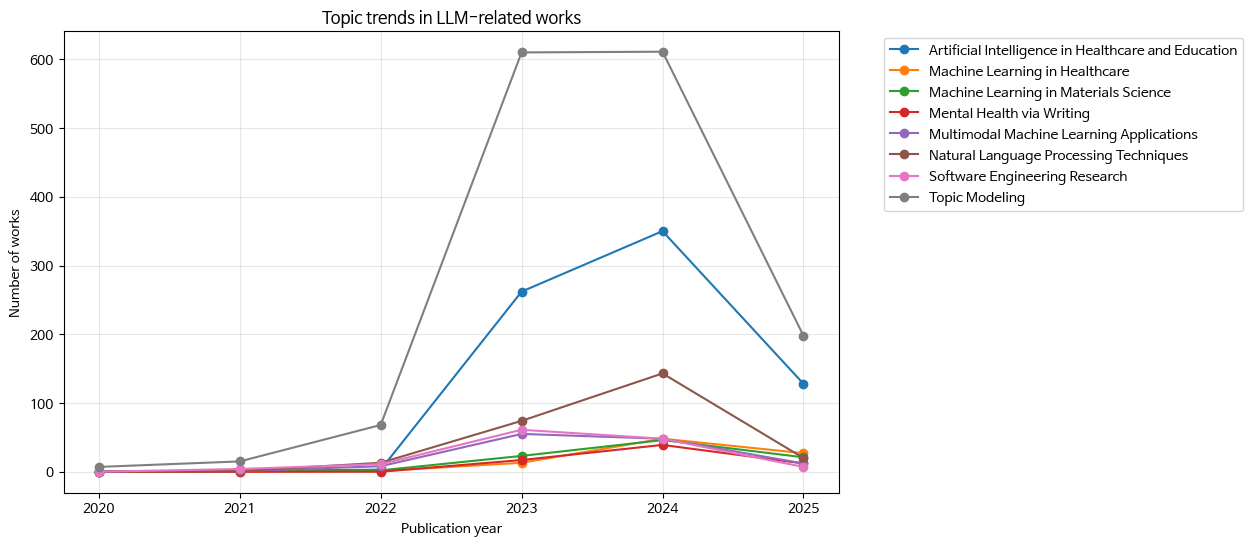

In [ ]:
plt.figure(figsize=(10, 6))
for topic in topic_year_pivot.columns:
    plt.plot(topic_year_pivot.index, topic_year_pivot[topic], marker="o", label=topic)

plt.title("Topic trends in LLM-related works")
plt.xlabel("Publication year")
plt.ylabel("Number of works")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

## 13. Abstract 복원
OpenAlex의 abstract는 `abstract_inverted_index` (`{단어: [위치]}`) 형태로 들어있음. (저작권 이슈)

토픽모델링에 쓰기 위해 일반 문장 및 문단 형태로 복원이 필요.

In [ ]:
def reconstruct_abstract(abstract_inverted_index):
    if not abstract_inverted_index:
        return None

    position_to_word = {}
    for word, positions in abstract_inverted_index.items():
        for position in positions:
            position_to_word[position] = word

    return " ".join(
        position_to_word[position]
        for position in sorted(position_to_word)
    )


df["abstract"] = [
    reconstruct_abstract(work.get("abstract_inverted_index"))
    for work in works
]

abstract_df = df.dropna(subset=["abstract"]).copy()
abstract_df["abstract_length"] = abstract_df["abstract"].str.split().str.len()

print("전체 논문 수:", len(df))
print("abstract가 있는 논문 수:", len(abstract_df))
print("abstract 보유 비율:", f"{len(abstract_df) / len(df):.1%}")

abstract_df[["title", "abstract", "primary_topic"]].head(3)

전체 논문 수: 5000
abstract가 있는 논문 수: 4288
abstract 보유 비율: 85.8%


,title,abstract,primary_topic
2,Large language models encode clinical knowledge,Abstract Large language models (LLMs) have dem...,Topic Modeling
3,A Survey on Evaluation of Large Language Models,Large language models (LLMs) are gaining incre...,Topic Modeling
4,Performance of ChatGPT on USMLE: Potential for...,We evaluated the performance of a large langua...,Artificial Intelligence in Healthcare and Educ...


## 14. Abstract 기반 토픽모델링
이제 OpenAlex의 topic이 아닌, abstract 텍스트를 기반으로 자체 토픽 분석 진행.

복원한 abstract을 바탕으로 문서-단어 행렬을 만들고, LDA로 토픽 추정.

In [ ]:
N_MODEL_TOPICS = 8
N_TOP_WORDS = 12
MAX_TOPIC_FEATURES = 3000

# 너무 짧은 abstract는 토픽모델링에 노이즈가 될 수 있어 제외합니다.
topic_model_df = abstract_df[abstract_df["abstract_length"] >= 40].copy()

if len(topic_model_df) < 20:
    raise ValueError("토픽모델링을 하려면 abstract가 있는 논문이 최소 20건 정도 필요합니다. MAX_RECORDS나 검색어를 조정해보세요.")

custom_stop_words = [
    "large", "language", "model", "models", "llm", "llms",
    "paper", "study", "research", "approach", "method", "methods",
    "result", "results", "task", "tasks"
]

base_stop_words = list(CountVectorizer(stop_words="english").get_stop_words())
stop_words = sorted(set(base_stop_words + custom_stop_words))

vectorizer = CountVectorizer(
    stop_words=stop_words,
    max_df=0.85,
    min_df=5,
    max_features=MAX_TOPIC_FEATURES,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z-]{2,}\b"
)

doc_term_matrix = vectorizer.fit_transform(topic_model_df["abstract"])
feature_names = np.array(vectorizer.get_feature_names_out())

if doc_term_matrix.shape[1] < 10:
    raise ValueError("토픽모델링에 사용할 단어가 너무 적습니다. min_df를 낮추거나 데이터를 더 수집해보세요.")

n_topics = min(
    N_MODEL_TOPICS,
    max(2, len(topic_model_df) // 20),
    max(2, doc_term_matrix.shape[1] // 5)
)

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="online",
    random_state=42,
    n_jobs=-1
)

doc_topic_matrix = lda_model.fit_transform(doc_term_matrix)
topic_model_df["model_topic_id"] = doc_topic_matrix.argmax(axis=1)
topic_model_df["model_topic_weight"] = doc_topic_matrix.max(axis=1)

print("토픽모델링에 사용한 논문 수:", len(topic_model_df))
print("사용한 단어/구문 수:", doc_term_matrix.shape[1])
print("추정 토픽 수:", n_topics)

토픽모델링에 사용한 논문 수: 4123
사용한 단어/구문 수: 3000
추정 토픽 수: 8


In [ ]:
topic_terms = []

for topic_id, topic_weights in enumerate(lda_model.components_):
    top_indices = topic_weights.argsort()[::-1][:N_TOP_WORDS]
    terms = feature_names[top_indices].tolist()
    topic_terms.append({
        "model_topic_id": topic_id,
        "top_terms": ", ".join(terms),
        "num_works": int((topic_model_df["model_topic_id"] == topic_id).sum())
    })

topic_terms_df = pd.DataFrame(topic_terms)

TOPIC_LABELS = {
    0: "멀티모달·보안/탐지",
    1: "데이터·학습 성능",
    2: "의료·임상 평가",
    3: "추론·사용 연구",
    4: "지식·NLP 추론",
    5: "코드·사용자 피드백",
    6: "응용·전망 리뷰",
    7: "헬스·사회적 이슈",
}

topic_terms_df["model_topic"] = topic_terms_df["model_topic_id"].map(TOPIC_LABELS)
topic_model_df["model_topic"] = topic_model_df["model_topic_id"].map(TOPIC_LABELS)

topic_terms_df[["model_topic_id", "model_topic", "top_terms", "num_works"]]

,model_topic_id,model_topic,top_terms,num_works
0,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",275
1,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",1002
2,2,의료·임상 평가,"clinical, gpt-, medical, accuracy, performance...",592
3,3,추론·사용 연구,"reasoning, human, using, use, text, used, stud...",394
4,4,지식·NLP 추론,"knowledge, natural, reasoning, processing, tex...",649
5,5,코드·사용자 피드백,"code, user, feedback, systems, users, generati...",366
6,6,응용·전망 리뷰,"data, potential, applications, challenges, rev...",731
7,7,헬스·사회적 이슈,"health, bias, social, mental, org, www, chatbo...",114


In [ ]:
top_examples_by_model_topic = (
    topic_model_df.sort_values(["model_topic_id", "model_topic_weight"], ascending=[True, False])
    .groupby("model_topic_id")
    .head(3)[["model_topic_id", "model_topic", "model_topic_weight", "publication_year", "title", "primary_topic"]]
)

top_examples_by_model_topic

,model_topic_id,model_topic,model_topic_weight,publication_year,title,primary_topic
88,0,멀티모달·보안/탐지,0.986311,2023,Large Language Models for Software Engineering...,Business Process Modeling and Analysis
1649,0,멀티모달·보안/탐지,0.986311,2023,Large Language Models for Software Engineering...,Software Engineering Research
912,0,멀티모달·보안/탐지,0.972629,2024,Applying Large Language Models to Power System...,Smart Grid Security and Resilience
2344,1,데이터·학습 성능,0.992627,2023,CodeT5+: Open Code Large Language Models for C...,Natural Language Processing Techniques
109,1,데이터·학습 성능,0.991728,2023,CodeT5+: Open Code Large Language Models for C...,Natural Language Processing Techniques
3202,1,데이터·학습 성능,0.989691,2023,PolyLM: An Open Source Polyglot Large Language...,Topic Modeling
799,2,의료·임상 평가,0.995292,2025,Physician- and Large Language Model–Generated ...,Machine Learning in Healthcare
593,2,의료·임상 평가,0.994995,2024,Quality of Large Language Model Responses to R...,Artificial Intelligence in Healthcare and Educ...
2417,2,의료·임상 평가,0.994844,2024,Large Language Models for Simplified Intervent...,Artificial Intelligence in Healthcare and Educ...
6,3,추론·사용 연구,0.917014,2021,Evaluating Large Language Models Trained on Code,Software Engineering Research


## 15. 우리가 추출한 토픽과 OpenAlex Topic 비교하기
LDA로 추정한 토픽과 OpenAlex의 `primary_topic`의 비교.

둘이 꼭 같아야 하는 것은 아님.

* OpenAlex Topic: 전체 학술 지형 속에서 붙은 분류
* LDA 토픽: 오늘 수집한 LLM 검색 결과 안에서 abstract 단어 분포를 바탕으로 추정한 묶음

In [ ]:
model_openalex_topic_counts = (
    topic_model_df.dropna(subset=["primary_topic"])
    .groupby(["model_topic_id", "model_topic", "primary_topic"])
    .size()
    .reset_index(name="num_works")
    .sort_values(["model_topic_id", "num_works"], ascending=[True, False])
)

model_topic_sizes = (
    topic_model_df.groupby(["model_topic_id", "model_topic"])
    .size()
    .rename("model_topic_total")
    .reset_index()
)

topic_labels = topic_terms_df[["model_topic_id", "model_topic", "top_terms"]]

model_openalex_top_topics = (
    model_openalex_topic_counts
    .merge(model_topic_sizes, on=["model_topic_id", "model_topic"], how="left")
    .assign(share=lambda x: x["num_works"] / x["model_topic_total"])
    .groupby("model_topic_id")
    .head(5)
    .merge(topic_labels, on=["model_topic_id", "model_topic"], how="left")
    [["model_topic_id", "model_topic", "top_terms", "primary_topic", "num_works", "share"]]
)

model_openalex_top_topics

,model_topic_id,model_topic,top_terms,primary_topic,num_works,share
0,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",Topic Modeling,53,0.192727
1,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",Natural Language Processing Techniques,18,0.065455
2,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",Network Security and Intrusion Detection,11,0.040000
3,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",Adversarial Robustness in Machine Learning,10,0.036364
4,0,멀티모달·보안/탐지,"multimodal, detection, visual, security, syste...",BIM and Construction Integration,10,0.036364
5,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",Topic Modeling,425,0.424152
6,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",Natural Language Processing Techniques,74,0.073852
7,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",Multimodal Machine Learning Applications,59,0.058882
8,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",Machine Learning in Materials Science,52,0.051896
9,1,데이터·학습 성능,"data, performance, training, datasets, dataset...",Software Engineering Research,34,0.033932


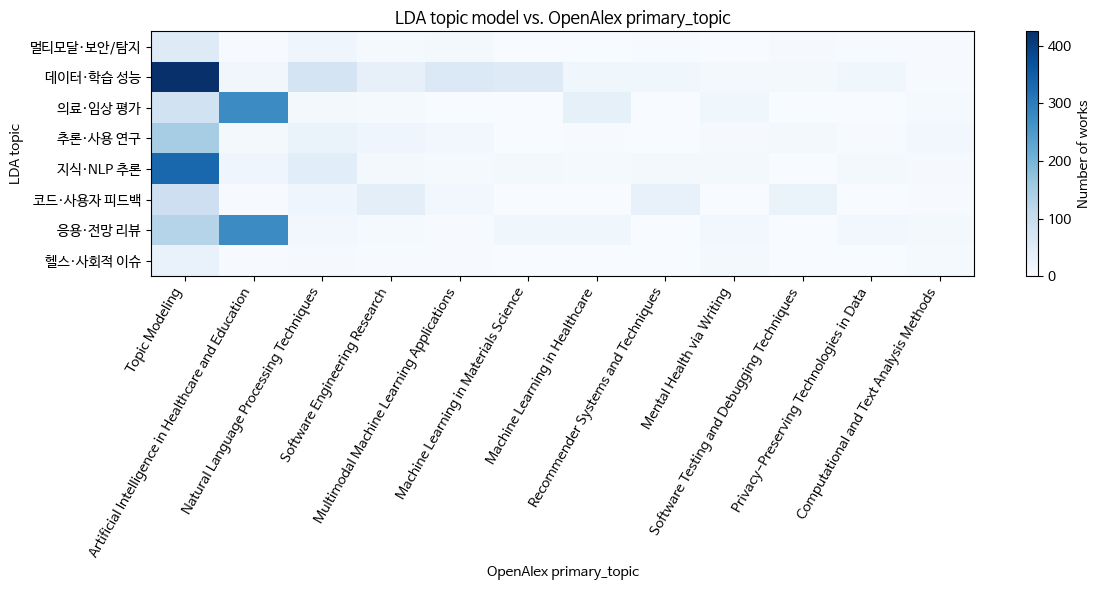

In [ ]:
top_openalex_topics_for_heatmap = (
    topic_model_df["primary_topic"]
    .value_counts()
    .head(12)
    .index
)

comparison_pivot = pd.crosstab(
    topic_model_df["model_topic"],
    topic_model_df["primary_topic"]
)
comparison_pivot = comparison_pivot.reindex(
    index=topic_terms_df["model_topic"],
    columns=top_openalex_topics_for_heatmap,
    fill_value=0
)

plt.figure(figsize=(12, 6))
plt.imshow(comparison_pivot.values, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of works")
plt.title("LDA topic model vs. OpenAlex primary_topic")
plt.xlabel("OpenAlex primary_topic")
plt.ylabel("LDA topic")
plt.xticks(
    ticks=range(len(comparison_pivot.columns)),
    labels=comparison_pivot.columns,
    rotation=60,
    ha="right"
)
plt.yticks(ticks=range(len(comparison_pivot.index)), labels=comparison_pivot.index)
plt.tight_layout()
plt.show()

In [ ]:
topic_comparison_summary = []

for topic_id in sorted(topic_model_df["model_topic_id"].unique()):
    topic_label = TOPIC_LABELS.get(topic_id, f"Topic {topic_id}")
    terms = topic_terms_df.loc[
        topic_terms_df["model_topic_id"] == topic_id,
        "top_terms"
    ].iloc[0]
    total_for_model_topic = (topic_model_df["model_topic_id"] == topic_id).sum()
    openalex_mix = (
        model_openalex_topic_counts[model_openalex_topic_counts["model_topic_id"] == topic_id]
        .head(3)
        .assign(share=lambda x: x["num_works"] / total_for_model_topic)
    )
    topic_comparison_summary.append({
        "model_topic_id": int(topic_id),
        "model_topic": topic_label,
        "model_top_terms": terms,
        "top_openalex_topics": openalex_mix[["primary_topic", "num_works", "share"]].to_dict(orient="records")
    })

print(json.dumps(topic_comparison_summary, ensure_ascii=False, indent=2)[:4000])

[
  {
    "model_topic_id": 0,
    "model_topic": "멀티모달·보안/탐지",
    "model_top_terms": "multimodal, detection, visual, security, systems, framework, potential, engineering, network, mllms, design, image",
    "top_openalex_topics": [
      {
        "primary_topic": "Topic Modeling",
        "num_works": 53,
        "share": 0.19272727272727272
      },
      {
        "primary_topic": "Natural Language Processing Techniques",
        "num_works": 18,
        "share": 0.06545454545454546
      },
      {
        "primary_topic": "Network Security and Intrusion Detection",
        "num_works": 11,
        "share": 0.04
      }
    ]
  },
  {
    "model_topic_id": 1,
    "model_topic": "데이터·학습 성능",
    "model_top_terms": "data, performance, training, datasets, dataset, fine-tuning, propose, learning, code, using, knowledge, state-of-the-art",
    "top_openalex_topics": [
      {
        "primary_topic": "Topic Modeling",
        "num_works": 425,
        "share": 0.4241516966067864
     

## 16. 최근에 떠오른 표현 찾기
* 토픽모델링: 논문들을 몇 개의 묶음으로 나누는 작업
* rising terms: 최근 abstract에서 어떤 표현이 더 두드러지는가?

2023년 이후 논문과 그 이전 논문의 TF-IDF 평균을 비교하여 최근에 상대적으로 많이 보이는 단어와 구문 확인해보기.

In [ ]:
RECENT_START_YEAR = 2023
N_RISING_TERMS = 30

term_df = abstract_df[abstract_df["abstract_length"] >= 40].copy()
recent_mask = term_df["publication_year"] >= RECENT_START_YEAR
baseline_mask = term_df["publication_year"] < RECENT_START_YEAR

if recent_mask.sum() < 10 or baseline_mask.sum() < 10:
    raise ValueError("recent/baseline 구간 중 한쪽의 abstract가 너무 적습니다. RECENT_START_YEAR나 MAX_RECORDS를 조정해보세요.")

rising_stop_words = [
    "large", "language", "model", "models", "large language", "language model",
    "llm", "llms", "paper", "study", "research", "approach", "method", "methods",
    "result", "results", "task", "tasks", "show", "shows", "based"
]

term_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=5,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z-]{2,}\b"
)

term_matrix = term_vectorizer.fit_transform(term_df["abstract"])
term_names = np.array(term_vectorizer.get_feature_names_out())

keep_terms = ~np.isin(term_names, rising_stop_words)
term_matrix = term_matrix[:, keep_terms]
term_names = term_names[keep_terms]

recent_mean = np.asarray(term_matrix[recent_mask.values].mean(axis=0)).ravel()
baseline_mean = np.asarray(term_matrix[baseline_mask.values].mean(axis=0)).ravel()

rising_terms_df = pd.DataFrame({
    "term": term_names,
    "recent_mean_tfidf": recent_mean,
    "baseline_mean_tfidf": baseline_mean,
})
rising_terms_df["tfidf_diff"] = rising_terms_df["recent_mean_tfidf"] - rising_terms_df["baseline_mean_tfidf"]
rising_terms_df["tfidf_ratio"] = rising_terms_df["recent_mean_tfidf"] / (rising_terms_df["baseline_mean_tfidf"] + 1e-6)

rising_terms_df = (
    rising_terms_df[rising_terms_df["recent_mean_tfidf"] > 0]
    .sort_values(["tfidf_diff", "tfidf_ratio"], ascending=False)
    .head(N_RISING_TERMS)
    .reset_index(drop=True)
)

rising_terms_df.head(15)

,term,recent_mean_tfidf,baseline_mean_tfidf,tfidf_diff,tfidf_ratio
0,chatgpt,0.014767,0.004771,0.009996,3.094666
1,challenges,0.012016,0.002901,0.009115,4.140136
2,health,0.009374,0.000508,0.008866,18.427153
3,models llms,0.014686,0.006145,0.008541,2.389632
4,applications,0.011863,0.003353,0.008510,3.536599
5,medical,0.014718,0.006369,0.008349,2.310406
6,potential,0.014732,0.006659,0.008073,2.212063
7,patient,0.007242,0.000000,0.007242,7242.407648
8,analysis,0.011046,0.003911,0.007135,2.823631
9,healthcare,0.008140,0.001068,0.007072,7.615182


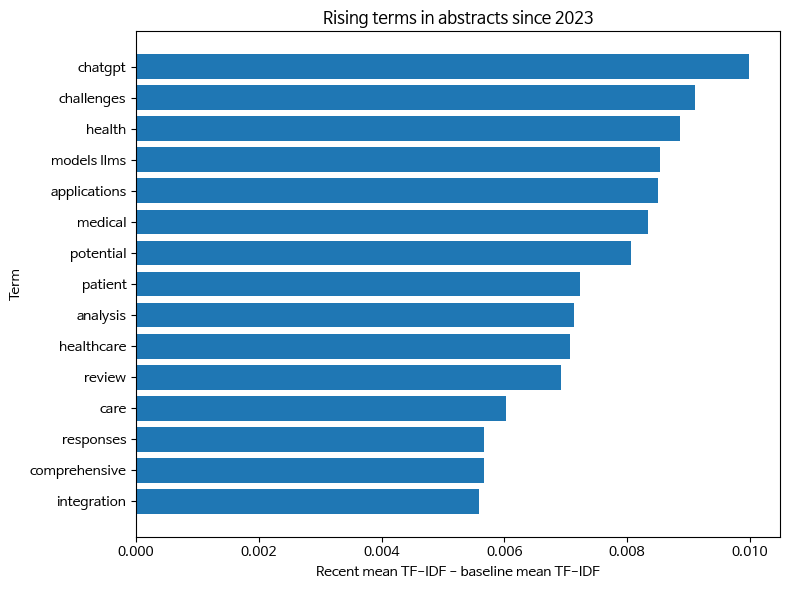

In [ ]:
top_rising_terms = rising_terms_df.head(15).sort_values("tfidf_diff")

plt.figure(figsize=(8, 6))
plt.barh(top_rising_terms["term"], top_rising_terms["tfidf_diff"])
plt.title(f"Rising terms in abstracts since {RECENT_START_YEAR}")
plt.xlabel("Recent mean TF-IDF - baseline mean TF-IDF")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

## 17. Rising terms는 OpenAlex Topic 어디에 나타날까?
rising terms가 OpenAlex의 어떤 primary_topic 아래에 많이 등장하는지 확인.

이 비교는 “키워드와 topic의 정답 매칭”이 아님!

OpenAlex Topic은 논문 전체를 분류한 값, rising terms는 abstract 안에서 최근 두드러진 표현. 둘이 어긋나는 지점은 오류가 아닌 관점 차이로 보는 것이 좋음.

In [ ]:
rising_term_topic_rows = []

for term in rising_terms_df["term"].head(10):
    subset = term_df[
        term_df["abstract"].str.contains(term, case=False, na=False, regex=False)
        & term_df["primary_topic"].notna()
    ]

    top_topics_for_term = subset["primary_topic"].value_counts().head(5)
    for primary_topic, num_works in top_topics_for_term.items():
        rising_term_topic_rows.append({
            "rising_term": term,
            "primary_topic": primary_topic,
            "num_works": int(num_works),
            "term_total_works": int(len(subset)),
            "share": num_works / len(subset) if len(subset) else 0
        })

rising_term_topic_df = pd.DataFrame(rising_term_topic_rows)
rising_term_topic_df

,rising_term,primary_topic,num_works,term_total_works,share
0,chatgpt,Artificial Intelligence in Healthcare and Educ...,312,780,0.400000
1,chatgpt,Topic Modeling,193,780,0.247436
2,chatgpt,Mental Health via Writing,16,780,0.020513
3,chatgpt,Natural Language Processing Techniques,13,780,0.016667
4,chatgpt,Computational and Text Analysis Methods,10,780,0.012821
5,challenges,Topic Modeling,338,1076,0.314126
6,challenges,Artificial Intelligence in Healthcare and Educ...,179,1076,0.166357
7,challenges,Natural Language Processing Techniques,44,1076,0.040892
8,challenges,Machine Learning in Healthcare,22,1076,0.020446
9,challenges,Multimodal Machine Learning Applications,21,1076,0.019517


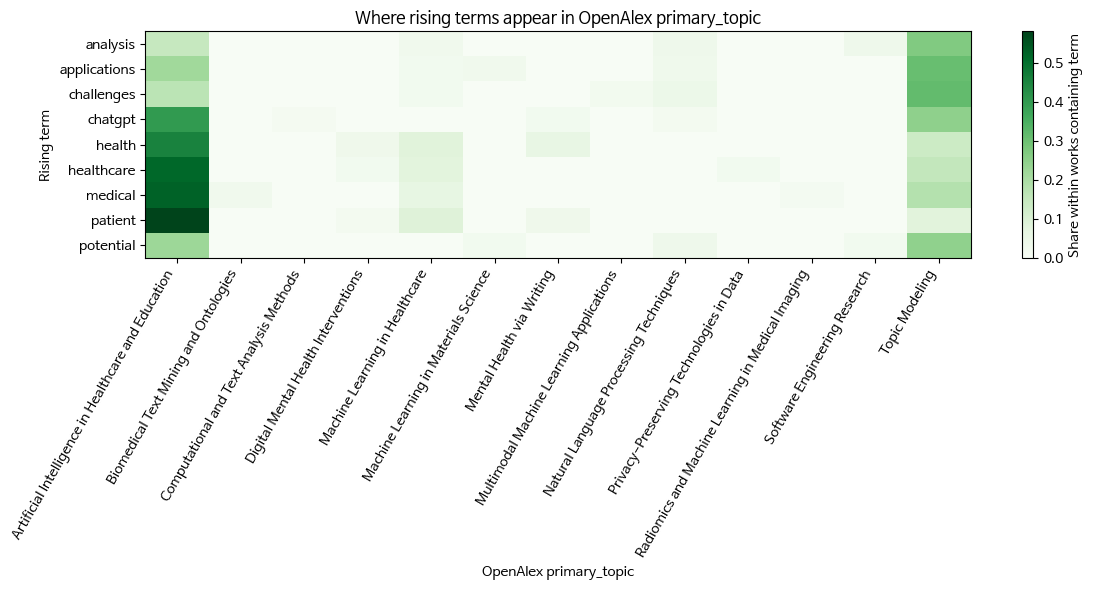

In [ ]:
if not rising_term_topic_df.empty:
    rising_term_topic_pivot = rising_term_topic_df.pivot_table(
        index="rising_term",
        columns="primary_topic",
        values="share",
        fill_value=0
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(rising_term_topic_pivot.values, aspect="auto", cmap="Greens")
    plt.colorbar(label="Share within works containing term")
    plt.title("Where rising terms appear in OpenAlex primary_topic")
    plt.xlabel("OpenAlex primary_topic")
    plt.ylabel("Rising term")
    plt.xticks(
        ticks=range(len(rising_term_topic_pivot.columns)),
        labels=rising_term_topic_pivot.columns,
        rotation=60,
        ha="right"
    )
    plt.yticks(ticks=range(len(rising_term_topic_pivot.index)), labels=rising_term_topic_pivot.index)
    plt.tight_layout()
    plt.show()
else:
    print("Rising term과 OpenAlex Topic을 함께 가진 논문이 충분하지 않습니다.")

## 19. 데이터 특성 및 주의점

실제 프로젝트에서 OpenAlex 데이터를 사용 시 확인할 점:

### 1. 검색어 정의 문제
`large language model`만 검색하면 관련 논문이 누락될 수 있음. 반대로 이니셜인 `LLM`은 다른 의미로 쓰이는 경우도 있어 노이즈가 생길 수 있음.

### 2. OpenAlex metadata 문제
- 저자 소속 정보가 없는 논문이 있음
- 기관 매핑이 완벽하지 않을 수 있음
- citation count는 데이터베이스마다 다름
- 최신 논문은 인용 수가 낮게 나타남
- abstract가 없는 논문은 텍스트 기반 분석에서 제외됨

### 3. API vs Snapshot
- 수천~수만 건: API로 충분
- 수십만 건 이상 반복 분석: Snapshot 또는 bulk data workflow 고려
- 전체 OpenAlex 기반 분석: Snapshot 권장

### 4. 해석할 때 기억할 점
이 노트북의 결과는 특정 검색어와 OpenAlex 메타데이터를 사용해 만든 탐색 결과. 검색식, 수집 시점, 결측값, 분류 체계가 모두 결과에 영향을 줌.


## 20. 확장 과제

1. 검색어를 `generative artificial intelligence`로 바꿔보기
2. `GPT`, `ChatGPT`, `Llama`, `instruction tuning`, `RLHF`를 OR 조건으로 확장하기
3. 특정 국가만 필터링하기
4. 특정 기관의 LLM 연구만 분석하기
5. 연도별 top cited works를 비교하기
6. OpenAlex Topic과 keyword search 결과를 비교하기
7. abstract 기반 토픽모델의 토픽 수와 stopword를 바꿔 결과 비교하기